# Figure 3: Zero-shot experiment results (with Whisper)

Plots zero-shot evaluation results including Whisper layerwise evaluations.
- **Loudness order discrimination** (speech commands level)
- **Melody match** (NSynth)
- **Mandarin tone discrimination**

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.container import BarContainer
import sys

sys.path.insert(0, str(Path("../").resolve()))

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    model_label,
    plot_grouped_bars,
    set_bar_labels,
    plot_sequential_bars,
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

%matplotlib inline

fig_out_dir = Path("CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)

## Load CochCNN9 zero-shot result CSVs

In [2]:
RESULTS_DIR = Path("/mnt/home/igriffith/ceph/projects/cochdnn/results_dfs")
DEFAULT_LAYER = "relu4"


def _layer_from_filename(path):
    stem = path.stem
    if "_results_" in stem:
        suffix = stem.split("_results_", 1)[-1]
        return suffix if suffix else DEFAULT_LAYER
    return DEFAULT_LAYER


def _load_task_csvs(glob_pattern):
    paths = sorted(RESULTS_DIR.glob(glob_pattern))
    if not paths:
        return pd.DataFrame()
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["layer"] = _layer_from_filename(p)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


speech_loudness_df = _load_task_csvs("zero_shot_speech_commands_level_discrimination_results*v2.csv")
model_name_map = {model: model_name for model, model_name in speech_loudness_df[["model", "model_name"]].dropna().drop_duplicates().values}
speech_loudness_df["model_name"] = speech_loudness_df["model"].map(model_name_map)
speech_loudness_df["task"] = "Loudness order discrimination"
speech_loudness_df.layer = speech_loudness_df.layer.str.replace("_v2", "")

melody_df = _load_task_csvs("zero_shot_nsynth_melody_match_results*v2.csv")
melody_df["task"] = "Melody match"
melody_df.layer = melody_df.layer.str.replace("_v2", "")

mandarin_df = _load_task_csvs("zero_shot_mandarin_tone_results*v2.csv")
mandarin_df["task"] = "Mandarin tone discrimination"
mandarin_df.layer = mandarin_df.layer.str.replace("_v2", "")

results_df = pd.concat([speech_loudness_df, melody_df, mandarin_df], ignore_index=True)
results_df.model_name = results_df.model_name.str.replace("DNN", "CNN")
no_byola_df = results_df[results_df["model_name"] != "byol-a"].copy()

print(f"Speech commands: {len(speech_loudness_df)} rows")
print(f"NSynth melody:  {len(melody_df)} rows")
print(f"Mandarin tone:  {len(mandarin_df)} rows")
print(f"Models: {no_byola_df.model_name.unique().tolist()}")

Speech commands: 28000 rows
NSynth melody:  67200 rows
Mandarin tone:  27986 rows
Models: ['CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5', 'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5', 'CochCNN9 supervised word', 'CochCNN9 supervised audioset', 'CochCNN9 supervised multi-task', 'CochCNN9 scaled supervised', 'CochCNN9 random weights']


## Load Whisper layerwise results

In [3]:
whisper_mandarin = pd.read_csv(RESULTS_DIR / "zero_shot_mandarin_whisper_layerwise.csv")
whisper_mandarin["task"] = "Mandarin tone discrimination"

whisper_nsynth = pd.read_csv(RESULTS_DIR / "zero_shot_nsynth_whisper_layerwise.csv")
whisper_nsynth["task"] = "Melody match"

whisper_speech = pd.read_csv(RESULTS_DIR / "zero_shot_speech_commands_whisper_layerwise.csv")
whisper_speech["task"] = "Loudness order discrimination"

whisper_all = pd.concat([whisper_mandarin, whisper_nsynth, whisper_speech], ignore_index=True)

print(f"Whisper total rows: {len(whisper_all)}")
for task in whisper_all.task.unique():
    sub = whisper_all[whisper_all.task == task]
    print(f"  {task}: {len(sub)} rows, models={sub.model_name.unique().tolist()}")
    print(f"    layers: {sub.layer.unique().tolist()}")

Whisper total rows: 554337
  Mandarin tone discrimination: 125937 rows, models=['Whisper tiny', 'Whisper medium', 'Whisper large-v3']
    layers: ['encoder_block_0', 'encoder_block_1', 'encoder_block_2', 'encoder_block_3', 'ln_post', 'encoder_block_4', 'encoder_block_5', 'encoder_block_6', 'encoder_block_7', 'encoder_block_8', 'encoder_block_9', 'encoder_block_10', 'encoder_block_11', 'encoder_block_12', 'encoder_block_13', 'encoder_block_14', 'encoder_block_15', 'encoder_block_16', 'encoder_block_17', 'encoder_block_18', 'encoder_block_19', 'encoder_block_20', 'encoder_block_21', 'encoder_block_22', 'encoder_block_23', 'encoder_block_24', 'encoder_block_25', 'encoder_block_26', 'encoder_block_27', 'encoder_block_28', 'encoder_block_29', 'encoder_block_30', 'encoder_block_31']
  Melody match: 302400 rows, models=['Whisper tiny', 'Whisper medium', 'Whisper large-v3']
    layers: ['encoder_block_0', 'encoder_block_1', 'encoder_block_2', 'encoder_block_3', 'ln_post', 'encoder_block_4', 'e

## Whisper per-layer accuracy

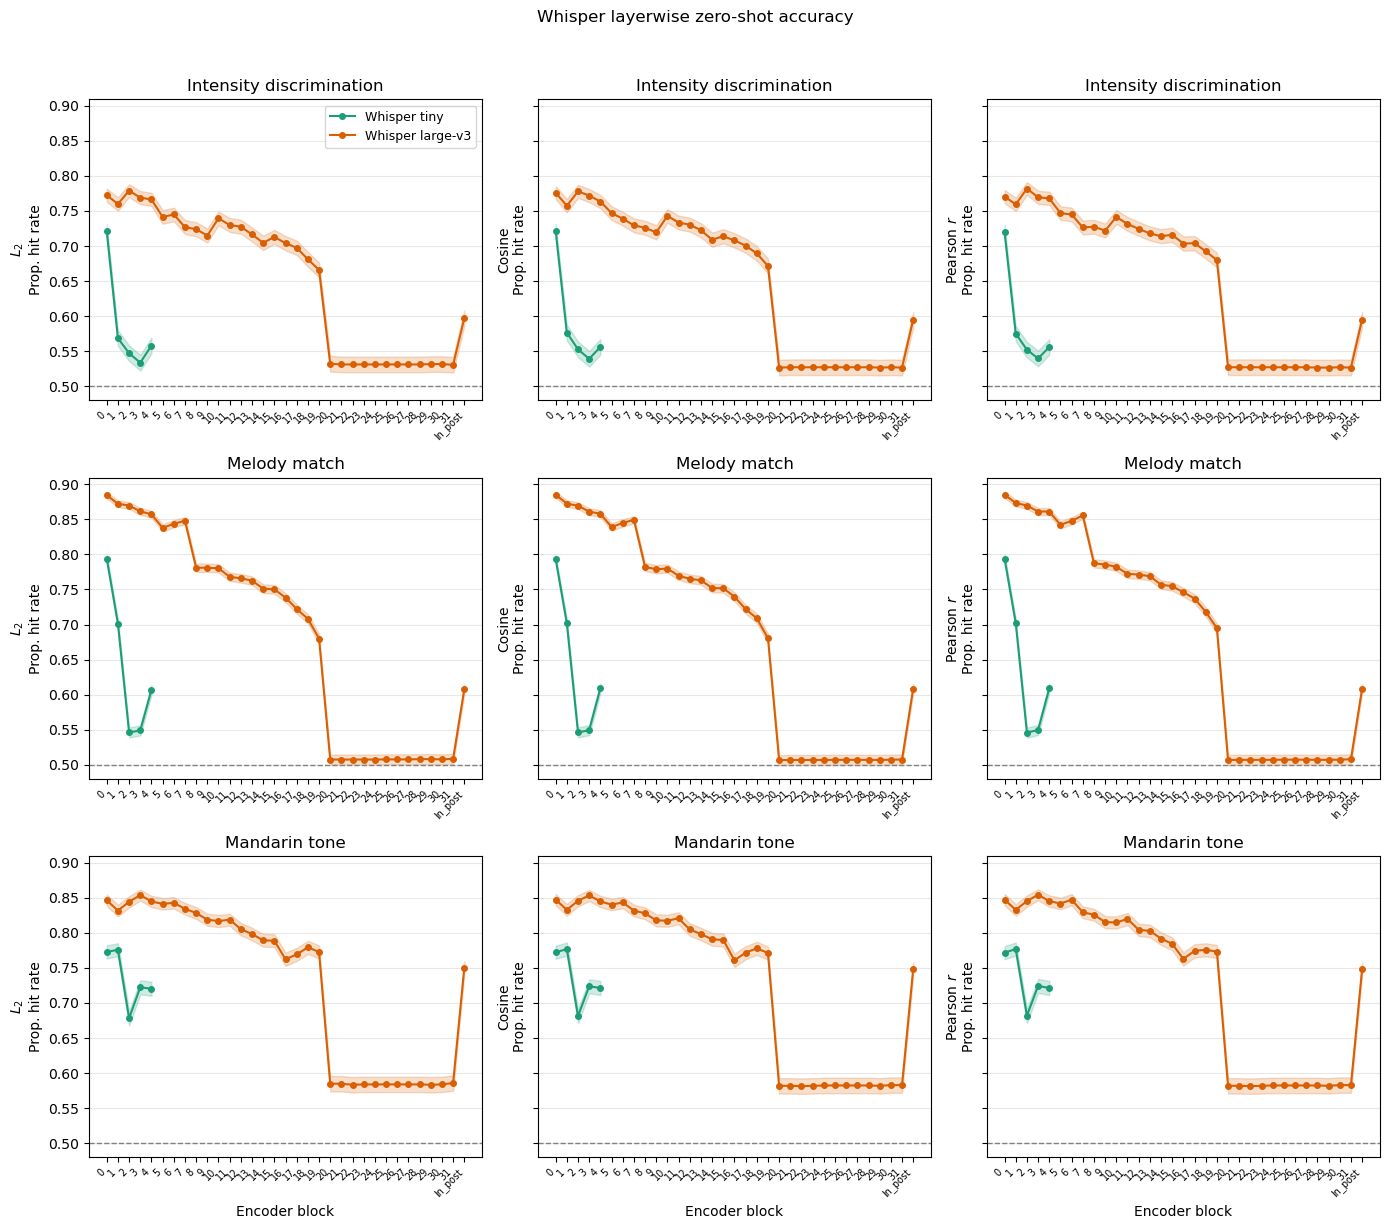

In [4]:
TASK_DISPLAY = {
    "Loudness order discrimination": "Intensity discrimination",
    "Melody match": "Melody match",
    "Mandarin tone discrimination": "Mandarin tone",
}

WHISPER_COLORS = {
    "Whisper tiny":     "#1b9e77",
    "Whisper large-v3": "#d95f02",
}


def layer_sort_key(layer_name):
    if layer_name == "ln_post":
        return 9999
    return int(layer_name.split("_")[-1])


METRIC_ROWS = [
    ("L2",      "sqr_l2_judgement", r"$L_2$"),
    ("Cosine",  "cos_judgement",    "Cosine"),
    ("Pearson", "r_judgement",      "Pearson $r$"),
]

TASK_COLS = [
    "Loudness order discrimination",
    "Melody match",
    "Mandarin tone discrimination",
]

n_rows = len(METRIC_ROWS)
n_cols = len(TASK_COLS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharey=True)

for col_idx, (metric_key, value_col, metric_label) in enumerate(METRIC_ROWS):
    for row_idx, task_name in enumerate(TASK_COLS):
        ax = axes[row_idx, col_idx]
        task_df = whisper_all[whisper_all.task == task_name]

        for model_name, color in WHISPER_COLORS.items():
            mdf = task_df[task_df.model_name == model_name]
            if mdf.empty:
                continue

            layers = sorted(mdf.layer.unique(), key=layer_sort_key)
            means = mdf.groupby("layer")[value_col].mean().reindex(layers)
            sems = mdf.groupby("layer")[value_col].sem().reindex(layers)

            x = np.arange(len(layers))
            ax.plot(x, means.values, "-o", color=color, label=model_name, markersize=4, linewidth=1.5)
            ax.fill_between(x, means.values - sems.values, means.values + sems.values, alpha=0.2, color=color)

            ax.set_xticks(x)
            tick_labels = [l.replace("encoder_block_", "") for l in layers]
            ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7)

        ax.set_title(TASK_DISPLAY.get(task_name, task_name))
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Encoder block")
        ax.set_ylabel(f"{metric_label}\nProp. hit rate")

axes[0, 0].legend(fontsize=9, loc="upper right")
fig.suptitle("Whisper layerwise zero-shot accuracy", y=1.02)
plt.tight_layout()
# plt.savefig(fig_out_dir / "whisper_layerwise_zero_shot.pdf", bbox_inches="tight")
plt.show()

## Load AudioMAE layerwise results

In [5]:
audiomae_mandarin_path = RESULTS_DIR / "zero_shot_mandarin_audiomae_layerwise.csv"
audiomae_nsynth_path = RESULTS_DIR / "zero_shot_nsynth_audiomae_layerwise.csv"
audiomae_speech_path = RESULTS_DIR / "zero_shot_speech_commands_audiomae_layerwise.csv"

audiomae_dfs = []
for path, task in [
    (audiomae_mandarin_path, "Mandarin tone discrimination"),
    (audiomae_nsynth_path, "Melody match"),
    (audiomae_speech_path, "Loudness order discrimination"),
]:
    if path.exists():
        df = pd.read_csv(path)
        df["task"] = task
        audiomae_dfs.append(df)
        print(f"  {task}: {len(df)} rows, layers={df.layer.unique().tolist()}")
    else:
        print(f"  MISSING {path}")

if audiomae_dfs:
    audiomae_all = pd.concat(audiomae_dfs, ignore_index=True)
    print(f"\nAudioMAE total rows: {len(audiomae_all)}")
else:
    audiomae_all = pd.DataFrame()
    print("No AudioMAE results found yet. Run eval_audiomae_layerwise_zero_shot.py first.")

  Mandarin tone discrimination: 25987 rows, layers=['block_0', 'block_1', 'block_2', 'block_3', 'block_4', 'block_5', 'block_6', 'block_7', 'block_8', 'block_9', 'block_10', 'block_11', 'norm']
  Melody match: 62400 rows, layers=['block_0', 'block_1', 'block_2', 'block_3', 'block_4', 'block_5', 'block_6', 'block_7', 'block_8', 'block_9', 'block_10', 'block_11', 'norm']
  Loudness order discrimination: 26000 rows, layers=['block_0', 'block_1', 'block_2', 'block_3', 'block_4', 'block_5', 'block_6', 'block_7', 'block_8', 'block_9', 'block_10', 'block_11', 'norm']

AudioMAE total rows: 114387


## AudioMAE per-layer accuracy

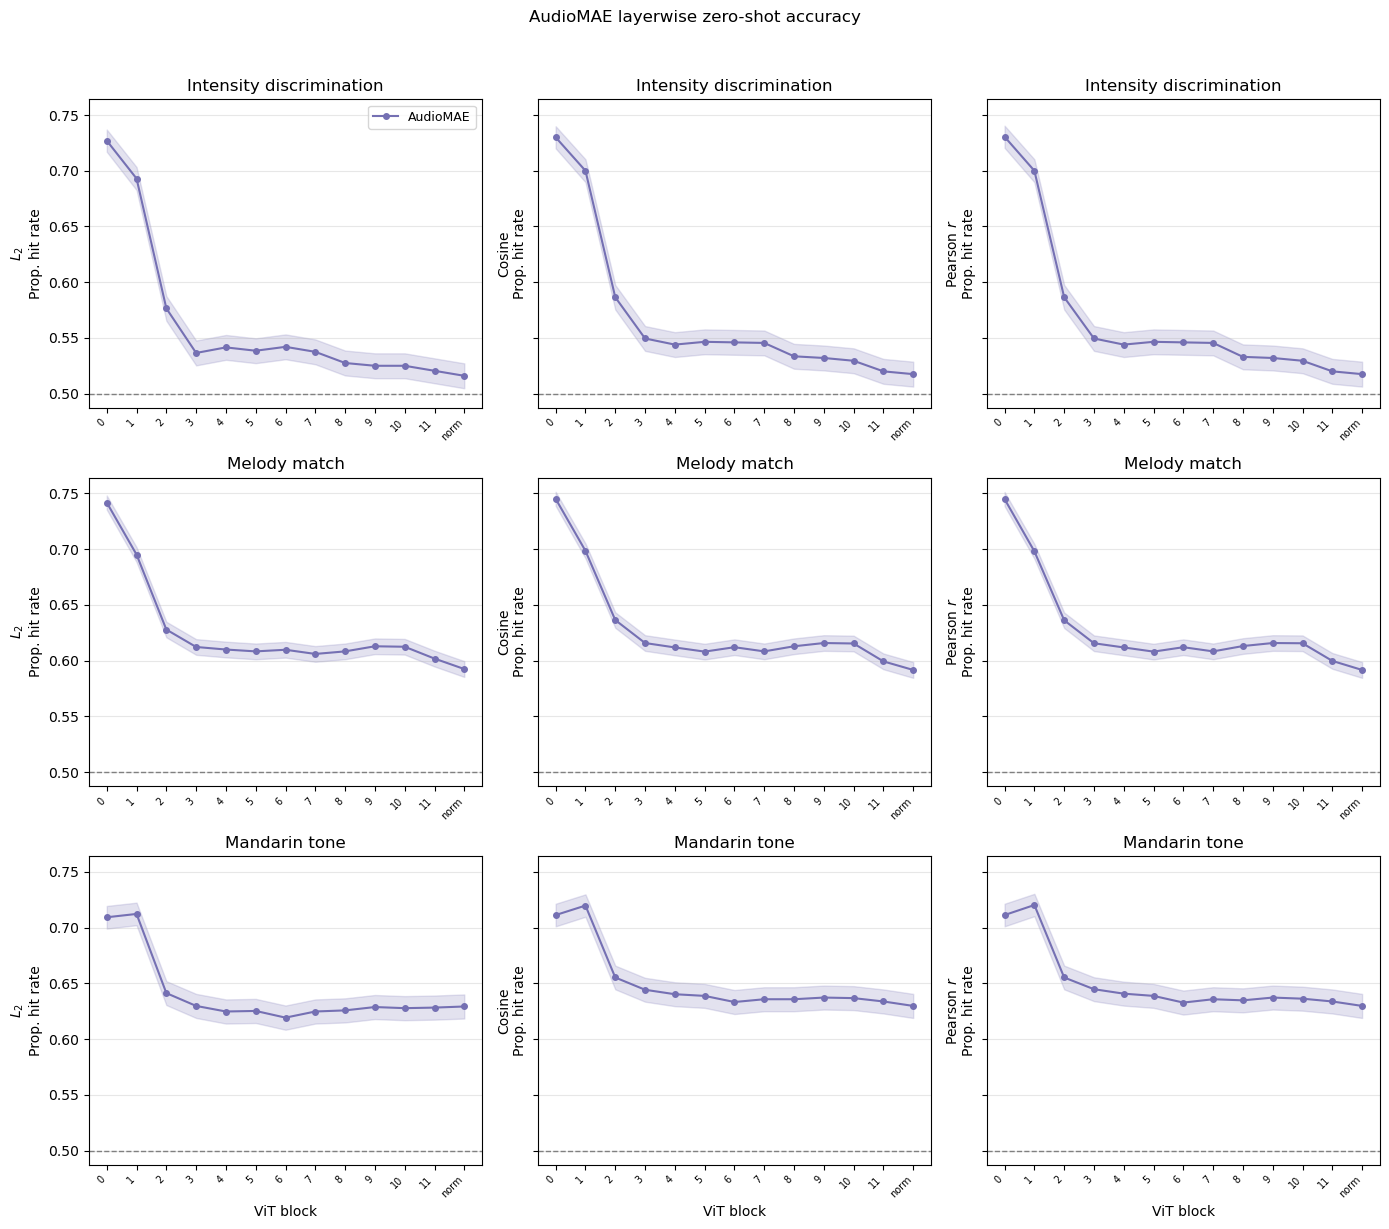

In [6]:
if not audiomae_all.empty:
    AUDIOMAE_COLOR = "#7570b3"

    def audiomae_layer_sort_key(layer_name):
        if layer_name == "norm":
            return 9999
        return int(layer_name.split("_")[-1])

    n_rows = len(METRIC_ROWS)
    n_cols = len(TASK_COLS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharey=True)

    for col_idx, (metric_key, value_col, metric_label) in enumerate(METRIC_ROWS):
        for row_idx, task_name in enumerate(TASK_COLS):
            ax = axes[row_idx, col_idx]
            task_df = audiomae_all[audiomae_all.task == task_name]

            if task_df.empty:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
            else:
                layers = sorted(task_df.layer.unique(), key=audiomae_layer_sort_key)
                means = task_df.groupby("layer")[value_col].mean().reindex(layers)
                sems = task_df.groupby("layer")[value_col].sem().reindex(layers)

                x = np.arange(len(layers))
                ax.plot(x, means.values, "-o", color=AUDIOMAE_COLOR, label="AudioMAE", markersize=4, linewidth=1.5)
                ax.fill_between(x, means.values - sems.values, means.values + sems.values, alpha=0.2, color=AUDIOMAE_COLOR)

                ax.set_xticks(x)
                tick_labels = [l.replace("block_", "") for l in layers]
                ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7)

            ax.set_title(TASK_DISPLAY.get(task_name, task_name))
            ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
            ax.grid(axis="y", alpha=0.3, zorder=-1)
            if row_idx == n_rows - 1:
                ax.set_xlabel("ViT block")
            ax.set_ylabel(f"{metric_label}\nProp. hit rate")

    axes[0, 0].legend(fontsize=9, loc="upper right")
    fig.suptitle("AudioMAE layerwise zero-shot accuracy", y=1.02)
    plt.tight_layout()
    # plt.savefig(fig_out_dir / "audiomae_layerwise_zero_shot.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Skipping AudioMAE per-layer plot — no data loaded.")

## Combined Whisper + AudioMAE per-layer comparison

Overlay all models on the same axes with normalized layer depth (0–1) on the x-axis
so models with different numbers of layers can be compared directly.

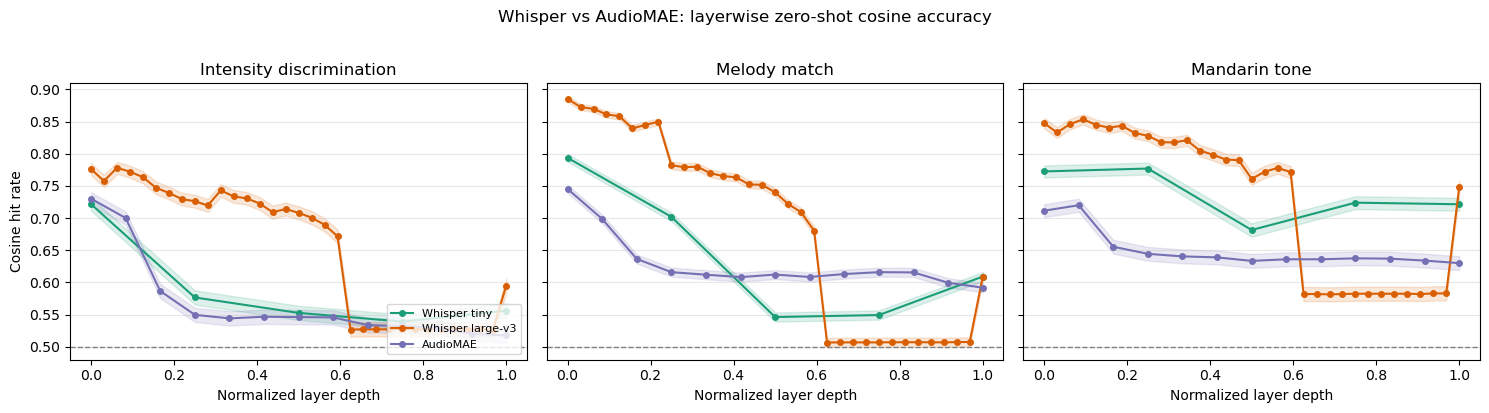

In [7]:
if not audiomae_all.empty:
    ALL_MODEL_COLORS = {
        **WHISPER_COLORS,
        "AudioMAE": AUDIOMAE_COLOR,
    }

    # Build a unified dataset with normalized layer depth
    def _add_norm_depth(df, sort_key_fn):
        """Add a 'layer_depth' column (0-1 normalized) to each model group."""
        records = []
        for model_name in df.model_name.unique():
            mdf = df[df.model_name == model_name].copy()
            layers = sorted(mdf.layer.unique(), key=sort_key_fn)
            depth_map = {l: i / max(len(layers) - 1, 1) for i, l in enumerate(layers)}
            mdf["layer_depth"] = mdf.layer.map(depth_map)
            records.append(mdf)
        return pd.concat(records, ignore_index=True)

    whisper_normed = _add_norm_depth(whisper_all, layer_sort_key)
    audiomae_normed = _add_norm_depth(audiomae_all, audiomae_layer_sort_key)
    combined = pd.concat([whisper_normed, audiomae_normed], ignore_index=True)

    value_col = "cos_judgement"
    fig, axes = plt.subplots(1, len(TASK_COLS), figsize=(15, 4), sharey=True)

    for col_idx, task_name in enumerate(TASK_COLS):
        ax = axes[col_idx]
        task_df = combined[combined.task == task_name]

        for model_name, color in ALL_MODEL_COLORS.items():
            mdf = task_df[task_df.model_name == model_name]
            if mdf.empty:
                continue
            grouped = mdf.groupby("layer_depth")[value_col]
            means = grouped.mean()
            sems = grouped.sem()
            x = means.index.values
            ax.plot(x, means.values, "-o", color=color, label=model_name, markersize=4, linewidth=1.5)
            ax.fill_between(x, means.values - sems.values, means.values + sems.values, alpha=0.15, color=color)

        ax.set_title(TASK_DISPLAY.get(task_name, task_name))
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.set_xlabel("Normalized layer depth")
        if col_idx == 0:
            ax.set_ylabel("Cosine hit rate")

    axes[0].legend(fontsize=8, loc="lower right")
    fig.suptitle("Whisper vs AudioMAE: layerwise zero-shot cosine accuracy", y=1.02)
    plt.tight_layout()
    # plt.savefig(fig_out_dir / "whisper_audiomae_layerwise_comparison.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Skipping combined plot — no AudioMAE data.")

## Main L2 bar plot: CochCNN9 models + Whisper + AudioMAE last layer

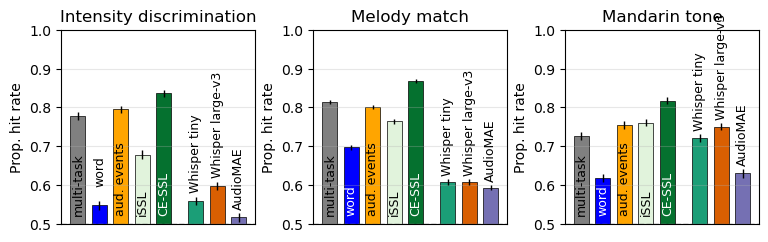

In [11]:
def _models_in_data(df):
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


main_plot_models = [
    "CochCNN9 supervised multi-task",
    "CochCNN9 supervised word",
    "CochCNN9 supervised audioset",
    "CochCNN9 ssl λ=0.0",
    "CochCNN9 ssl λ=0.5",
]

whisper_models = ["Whisper tiny", "Whisper large-v3"]
audiomae_models = ["AudioMAE"]
AUDIOMAE_BAR_COLOR = "#7570b3"

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)].copy()
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)


def _get_whisper_last_layer(model_name, task_df):
    mdf = task_df[task_df.model_name == model_name]
    if mdf.empty:
        return pd.DataFrame()
    block_layers = [l for l in mdf.layer.unique() if l.startswith("encoder_block_")]
    if not block_layers:
        return pd.DataFrame()
    last_block = max(block_layers, key=lambda l: int(l.split("_")[-1]))
    if "ln_post" in mdf.layer.unique():
        last_block = "ln_post"
    return mdf[mdf.layer == last_block].copy()


def _get_audiomae_last_layer(model_name, task_df):
    mdf = task_df[task_df.model_name == model_name]
    if mdf.empty:
        return pd.DataFrame()
    if "norm" in mdf.layer.unique():
        return mdf[mdf.layer == "norm"].copy()
    block_layers = [l for l in mdf.layer.unique() if l.startswith("block_")]
    if not block_layers:
        return pd.DataFrame()
    last_block = max(block_layers, key=lambda l: int(l.split("_")[-1]))
    return mdf[mdf.layer == last_block].copy()


METRIC_ROWS = [
    ("L2",      "sqr_l2_judgement",    r"$L_2$"),

]

TASK_COLS = [
    ("Loudness order discrimination", "Intensity discrimination"),
    ("Melody match",                  "Melody match"),
    ("Mandarin tone discrimination",  "Mandarin tone"),
]

n_rows = len(METRIC_ROWS)
n_cols = len(TASK_COLS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = axes[None, :]

for row_idx, (metric_key, value_col, metric_label) in enumerate(METRIC_ROWS):
    for col_idx, (task_name, task_label) in enumerate(TASK_COLS):
        ax = axes[row_idx, col_idx]

        task_coch = main_plot_df[(main_plot_df.layer == "relu4") & (main_plot_df.task == task_name)]
        task_whisper = whisper_all[whisper_all.task == task_name]

        all_models = list(hue_order)
        all_colors = dict(hue_dict)
        for wm in whisper_models:
            wdf = _get_whisper_last_layer(wm, task_whisper)
            if not wdf.empty:
                all_models.append(wm)
                all_colors[wm] = WHISPER_COLORS[wm]

        task_audiomae = audiomae_all[audiomae_all.task == task_name] if not audiomae_all.empty else pd.DataFrame()
        for am in audiomae_models:
            adf = _get_audiomae_last_layer(am, task_audiomae)
            if not adf.empty:
                all_models.append(am)
                all_colors[am] = AUDIOMAE_BAR_COLOR

        x_pos = 0
        bar_width = 0.7

        pretrained_models = set(whisper_models) | set(audiomae_models)

        for m_idx, m_name in enumerate(all_models):
            if m_name in whisper_models:
                mdf = _get_whisper_last_layer(m_name, task_whisper)
            elif m_name in audiomae_models:
                mdf = _get_audiomae_last_layer(m_name, task_audiomae)
            else:
                mdf = task_coch[task_coch.model_name.apply(normalize_model_name) == normalize_model_name(m_name)]

            if mdf.empty:
                continue

            mean_val = mdf[value_col].mean()
            sem_val = mdf[value_col].sem()
            color = all_colors.get(m_name, "#999999")

            prev_is_pretrained = m_idx > 0 and all_models[m_idx - 1] in pretrained_models
            if m_name in pretrained_models and m_idx > 0 and not prev_is_pretrained:
                x_pos += 0.5

            bar = ax.bar(x_pos, mean_val, width=bar_width, color=color,
                         edgecolor="black", linewidth=0.5,
                         yerr=sem_val, capsize=0, error_kw={"linewidth": 1})

            if m_name in pretrained_models:
                lbl = m_name
            else:
                lbl = model_label(m_name, use_ssl_names=True).replace("supervised ", "")

            if m_name in pretrained_models:
                ax.text(x_pos, mean_val + sem_val + 0.01, lbl,
                        ha="center", va="bottom", fontsize=9, rotation=90)
            else:
                white_text_substrs = ["word", "CE", "byol"]
                if "Loudness" in task_name:
                    white_text_substrs = ["CE", "byol"]

                set_bar_labels(ax, bar, [lbl],
                               white_text_substrs=white_text_substrs,
                               y_cut_for_olap=0.6, ymin_bars=0.52,
                               no_olap_pad=0.05, fontsize=9, x_shift_size=0.013)

            x_pos += 1

        if row_idx == 0:
            ax.set_title(task_label)
        ax.set_ylim(0.5, 1.0)
        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        # if col_idx == 0:
        ax.set_ylabel(f"Prop. hit rate")

ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright - xleft) / (ybottom - ytop)) * ratio)

fig.subplots_adjust(wspace=0.3, hspace=0.25)
# plt.savefig(fig_out_dir / "zero_shot_core_models_all_metrics_with_whisper.pdf", bbox_inches="tight")
plt.show()

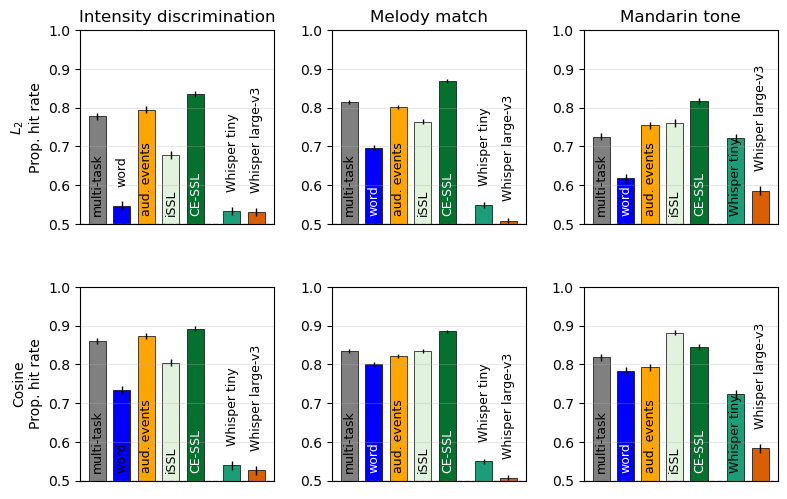

In [ ]:
def _models_in_data(df):
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


main_plot_models = [
    "CochCNN9 supervised multi-task",
    "CochCNN9 supervised word",
    "CochCNN9 supervised audioset",
    "CochCNN9 ssl λ=0.0",
    "CochCNN9 ssl λ=0.5",
]

whisper_models = ["Whisper tiny", "Whisper large-v3"]

main_plot_df = no_byola_df[no_byola_df.model_name.isin(main_plot_models)].copy()
hue_order = _models_in_data(main_plot_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)


def _get_whisper_last_layer(model_name, task_df):
    mdf = task_df[task_df.model_name == model_name]
    if mdf.empty:
        return pd.DataFrame()
    block_layers = [l for l in mdf.layer.unique() if l.startswith("encoder_block_")]
    if not block_layers:
        return pd.DataFrame()
    last_block = max(block_layers, key=lambda l: int(l.split("_")[-1]))
    if "ln_post" in mdf.layer.unique():
        last_block = "ln_post"
    return mdf[mdf.layer == last_block].copy()


METRIC_ROWS = [
    ("L2",      "sqr_l2_judgement",    r"$L_2$"),
    ("Cosine",  "cos_judgement",       "Cosine"),
    # ("Pearson", "r_judgement",         "Pearson $r$"),
]

TASK_COLS = [
    ("Loudness order discrimination", "Intensity discrimination"),
    ("Melody match",                  "Melody match"),
    ("Mandarin tone discrimination",  "Mandarin tone"),
]

n_rows = len(METRIC_ROWS)
n_cols = len(TASK_COLS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for row_idx, (metric_key, value_col, metric_label) in enumerate(METRIC_ROWS):
    for col_idx, (task_name, task_label) in enumerate(TASK_COLS):
        ax = axes[row_idx, col_idx]

        task_coch = main_plot_df[(main_plot_df.layer == "relu4") & (main_plot_df.task == task_name)]
        task_whisper = whisper_all[whisper_all.task == task_name]

        all_models = list(hue_order)
        all_colors = dict(hue_dict)
        for wm in whisper_models:
            wdf = _get_whisper_last_layer(wm, task_whisper)
            if not wdf.empty:
                all_models.append(wm)
                all_colors[wm] = WHISPER_COLORS[wm]

        x_pos = 0
        bar_width = 0.7

        for m_idx, m_name in enumerate(all_models):
            if m_name in whisper_models:
                mdf = _get_whisper_last_layer(m_name, task_whisper)
            else:
                mdf = task_coch[task_coch.model_name.apply(normalize_model_name) == normalize_model_name(m_name)]

            if mdf.empty:
                continue

            mean_val = mdf[value_col].mean()
            sem_val = mdf[value_col].sem()
            color = all_colors.get(m_name, "#999999")

            if m_name in whisper_models and m_idx > 0 and all_models[m_idx - 1] not in whisper_models:
                x_pos += 0.5

            bar = ax.bar(x_pos, mean_val, width=bar_width, color=color,
                         edgecolor="black", linewidth=0.5,
                         yerr=sem_val, capsize=0, error_kw={"linewidth": 1})

            if m_name in whisper_models:
                lbl = m_name
            else:
                lbl = model_label(m_name, use_ssl_names=True).replace("supervised ", "")

            white_text_substrs = ["word", "CE", "byol"]
            if "Loudness" in task_name:
                white_text_substrs = ["CE", "byol"]

            set_bar_labels(ax, bar, [lbl],
                           white_text_substrs=white_text_substrs,
                           y_cut_for_olap=0.6, ymin_bars=0.52,
                           no_olap_pad=0.05, fontsize=9, x_shift_size=0.013)

            x_pos += 1

        if row_idx == 0:
            ax.set_title(task_label)
        ax.set_ylim(0.5, 1.0)
        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        if col_idx == 0:
            ax.set_ylabel(f"{metric_label}\nProp. hit rate")

ratio = 1.0
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright - xleft) / (ybottom - ytop)) * ratio)

fig.subplots_adjust(wspace=0.3, hspace=0.25)
# plt.savefig(fig_out_dir / "zero_shot_core_models_all_metrics_with_whisper.pdf", bbox_inches="tight")
plt.show()